In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df_train = pd.read_csv('D:/LAI/data/train.csv')
df_test = pd.read_csv('D:/LAI/data/test.csv')
df_val = pd.read_csv('D:/LAI/data/val.csv')
df = pd.concat([df_train, df_test])

label_column = 'label'

X_train = df_train['processed_post']
y_train = df_train[label_column]

X_test = df_test['processed_post']
y_test = df_test[label_column]

X_val = df_val['processed_post']
y_val = df_val[label_column]

tfidf = TfidfVectorizer(max_features=1000)
X_train = tfidf.fit_transform(X_train).toarray()
X_test = tfidf.transform(X_test).toarray()
X_val = tfidf.transform(X_val).toarray()

In [3]:
# Step 4: Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.39871953100894786
Accuracy: 0.3987


Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.35      0.33      3664
           1       0.44      0.41      0.43      4801
           2       0.44      0.42      0.43      4499

    accuracy                           0.40     12964
   macro avg       0.40      0.40      0.40     12964
weighted avg       0.40      0.40      0.40     12964

Confusion Matrix:
[[1286 1171 1207]
 [1592 1978 1231]
 [1295 1299 1905]]


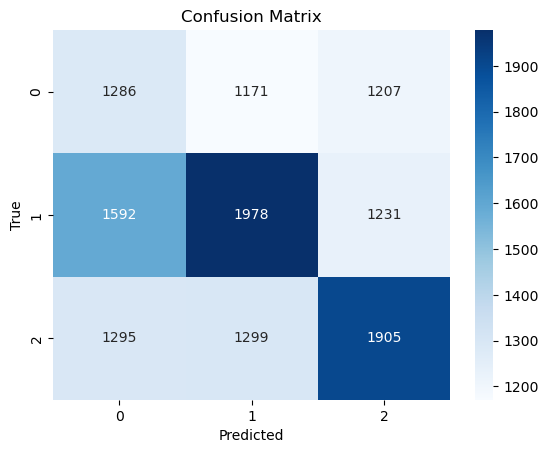

In [4]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [5]:
param_grid = [
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
        'l1_ratio': [0.3, 0.5, 0.7, 0.9],  # Slightly extended l1_ratio range
    },
    {
        'penalty': [None],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
]

grid_search = GridSearchCV(estimator=model, param_grid = param_grid, scoring='accuracy', n_jobs=-1)
grid_result = grid_search.fit(X_val, y_val)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.640227 using {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.602998 (0.019150) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.602867 (0.019261) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.581818 (0.023496) with: {'C': 100, 'penalty': 'l2', 'solver': 'sag'}
0.616022 (0.017655) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.616549 (0.015875) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.614048 (0.015246) with: {'C': 10, 'penalty': 'l2', 'solver': 'sag'}
0.640227 (0.012996) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.639701 (0.013222) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.639833 (0.013014) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'sag'}
0.613918 (0.005127) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.614707 (0.005584) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.614707 (0.006173) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'sag'}
0.434753 (0.009520) with: {'C': 0.01, 'penalty': 'l

In [6]:
# Extract the best parameters
best_params = grid_result.best_params_

# Update the model with the best parameters
best_model = LogisticRegression(**best_params)
best_model.fit(X_train, y_train) 

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.3987


Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.35      0.33      3664
           1       0.44      0.41      0.43      4801
           2       0.44      0.42      0.43      4499

    accuracy                           0.40     12964
   macro avg       0.40      0.40      0.40     12964
weighted avg       0.40      0.40      0.40     12964

Confusion Matrix:
[[1286 1171 1207]
 [1592 1978 1231]
 [1295 1299 1905]]


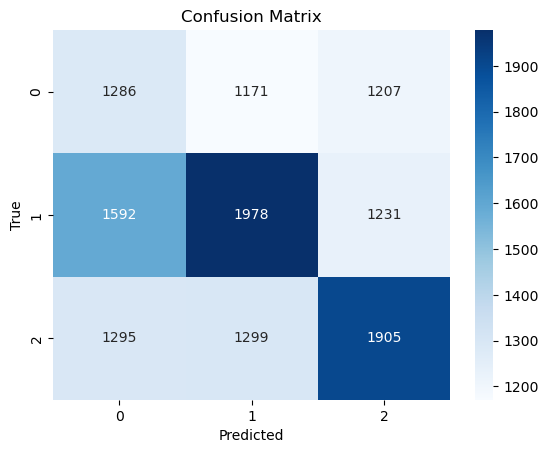

In [7]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [8]:
df_train_deb1000 = pd.read_csv('D:/LAI/data/train_debiased_1000.csv')
df_test_deb1000 = pd.read_csv('D:/LAI/data/test_debiased_1000.csv')
df_val_deb1000 = pd.read_csv('D:/LAI/data/val_debiased_1000.csv')

df_train_deb1000 = df_train_deb1000.dropna(subset=['debiased_post'])
df_test_deb1000 = df_test_deb1000.dropna(subset=['debiased_post'])
df_val_deb1000 = df_val_deb1000.dropna(subset=['debiased_post'])

label_column = 'label'

X_train_deb1000 = df_train_deb1000['debiased_post']
y_train_deb1000 = df_train_deb1000[label_column]

X_test_deb1000 = df_test_deb1000['debiased_post']
y_test_deb1000 = df_test_deb1000[label_column]

X_val_deb1000 = df_val_deb1000['debiased_post']
y_val_deb1000 = df_val_deb1000[label_column]

tfidf = TfidfVectorizer(max_features=1000)
X_train_deb1000 = tfidf.fit_transform(X_train_deb1000).toarray()
X_test_deb1000 = tfidf.transform(X_test_deb1000).toarray()
X_val_deb1000 = tfidf.transform(X_val_deb1000).toarray()

In [9]:
df_train_deb500 = pd.read_csv('D:/LAI/data/train_debiased_500.csv')
df_test_deb500 = pd.read_csv('D:/LAI/data/test_debiased_500.csv')
df_val_deb500 = pd.read_csv('D:/LAI/data/val_debiased_500.csv')

df_train_deb500 = df_train_deb500.dropna(subset=['debiased_post'])
df_test_deb500 = df_test_deb500.dropna(subset=['debiased_post'])
df_val_deb500 = df_val_deb500.dropna(subset=['debiased_post'])

label_column = 'label'

X_train_deb500 = df_train_deb500['debiased_post']
y_train_deb500 = df_train_deb500[label_column]

X_test_deb500 = df_test_deb500['debiased_post']
y_test_deb500 = df_test_deb500[label_column]

X_val_deb500 = df_val_deb500['debiased_post']
y_val_deb500 = df_val_deb500[label_column]

tfidf = TfidfVectorizer(max_features=1000)
X_train_deb500 = tfidf.fit_transform(X_train_deb500).toarray()
X_test_deb500 = tfidf.transform(X_test_deb500).toarray()
X_val_deb500 = tfidf.transform(X_val_deb500).toarray()

In [10]:
df_train_deb100 = pd.read_csv('D:/LAI/data/train_debiased_100.csv')
df_test_deb100 = pd.read_csv('D:/LAI/data/test_debiased_100.csv')
df_val_deb100 = pd.read_csv('D:/LAI/data/val_debiased_100.csv')

df_train_deb100 = df_train_deb100.dropna(subset=['debiased_post'])
df_test_deb100 = df_test_deb100.dropna(subset=['debiased_post'])
df_val_deb100 = df_val_deb100.dropna(subset=['debiased_post'])

label_column = 'label'

X_train_deb100 = df_train_deb100['debiased_post']
y_train_deb100 = df_train_deb100[label_column]

X_test_deb100 = df_test_deb100['debiased_post']
y_test_deb100 = df_test_deb100[label_column]

X_val_deb100 = df_val_deb100['debiased_post']
y_val_deb100 = df_val_deb100[label_column]

tfidf = TfidfVectorizer(max_features=1000)
X_train_deb100 = tfidf.fit_transform(X_train_deb100).toarray()
X_test_deb100 = tfidf.transform(X_test_deb100).toarray()
X_val_deb100 = tfidf.transform(X_val_deb100).toarray()

In [11]:
print("Using the debiased 1000 test set on the model trained with biased data")

# Make predictions on the test set
y_pred_deb1000 = best_model.predict(X_test_deb1000)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb1000, y_pred_deb1000)
print(f"Accuracy: {accuracy:.4f}")

Using the debiased 1000 test set on the model trained with biased data
Accuracy: 0.3476


Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.42      0.34      3664
           1       0.41      0.24      0.30      4801
           2       0.38      0.41      0.39      4497

    accuracy                           0.35     12962
   macro avg       0.36      0.35      0.34     12962
weighted avg       0.37      0.35      0.34     12962

Confusion Matrix:
[[1538  798 1328]
 [2019 1131 1651]
 [1842  819 1836]]


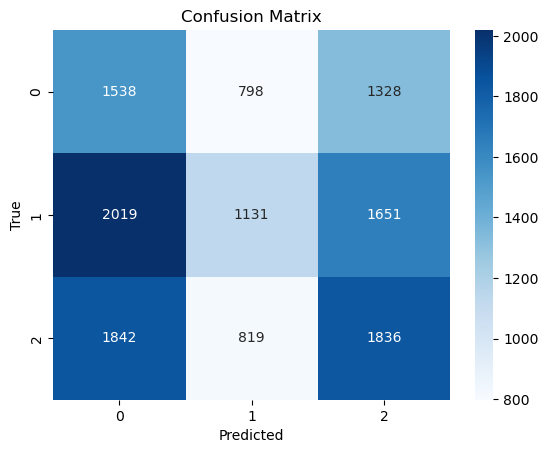

In [12]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb1000, y_pred_deb1000))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb1000, y_pred_deb1000)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [13]:
print("Using the debiased 500 test set on the model trained with biased data")

# Make predictions on the test set
y_pred_deb500 = best_model.predict(X_test_deb500)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb500, y_pred_deb500)
print(f"Accuracy: {accuracy:.4f}")

Using the debiased 500 test set on the model trained with biased data
Accuracy: 0.3539


Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.25      0.27      3664
           1       0.41      0.24      0.31      4801
           2       0.36      0.56      0.44      4497

    accuracy                           0.35     12962
   macro avg       0.35      0.35      0.34     12962
weighted avg       0.36      0.35      0.34     12962

Confusion Matrix:
[[ 918  736 2010]
 [1131 1159 2511]
 [1089  898 2510]]


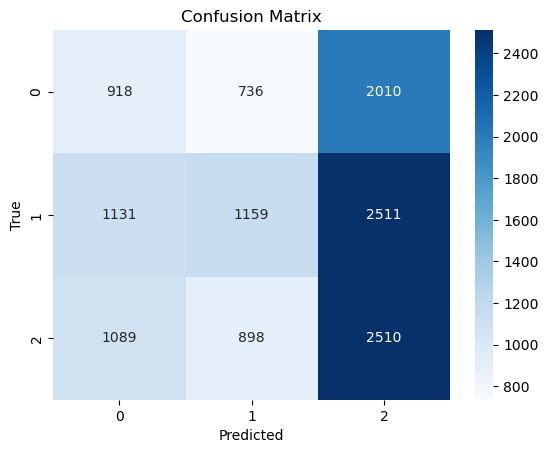

In [14]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb500, y_pred_deb500))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb500, y_pred_deb500)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [15]:
print("Using the debiased 100 test set on the model trained with biased data")

# Make predictions on the test set
y_pred_deb100 = best_model.predict(X_test_deb100)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb100, y_pred_deb100)
print(f"Accuracy: {accuracy:.4f}")

Using the debiased 100 test set on the model trained with biased data
Accuracy: 0.3270


Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.45      0.34      3664
           1       0.38      0.26      0.31      4801
           2       0.35      0.30      0.32      4497

    accuracy                           0.33     12962
   macro avg       0.34      0.34      0.33     12962
weighted avg       0.34      0.33      0.32     12962

Confusion Matrix:
[[1636  948 1080]
 [2160 1269 1372]
 [2077 1086 1334]]


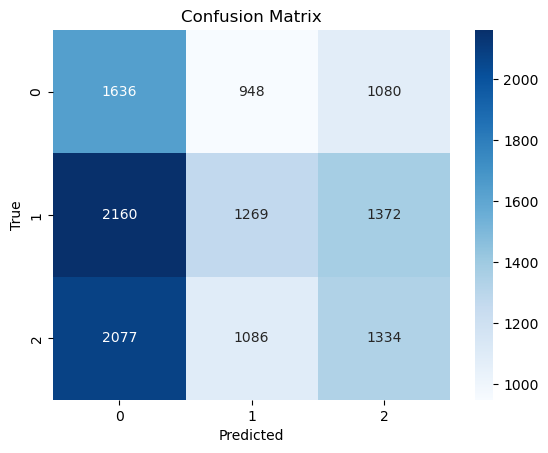

In [16]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb100, y_pred_deb100))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb100, y_pred_deb100)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

db1000

In [18]:
# Step 4: Train the model
model_deb1000 = LogisticRegression()
model_deb1000.fit(X_train_deb1000, y_train_deb1000)

# Step 5: Evaluate the model
accuracy = model_deb1000.score(X_test_deb1000, y_test_deb1000)
print(f"Accuracy: {accuracy}")

# Make predictions on the test set
y_pred_deb1000 = model_deb1000.predict(X_test_deb1000)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb1000, y_pred_deb1000)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.39893534948310444
Accuracy: 0.3989


Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.37      0.34      3664
           1       0.44      0.40      0.42      4801
           2       0.43      0.43      0.43      4497

    accuracy                           0.40     12962
   macro avg       0.40      0.40      0.40     12962
weighted avg       0.40      0.40      0.40     12962

Confusion Matrix:
[[1350 1126 1188]
 [1579 1906 1316]
 [1313 1269 1915]]


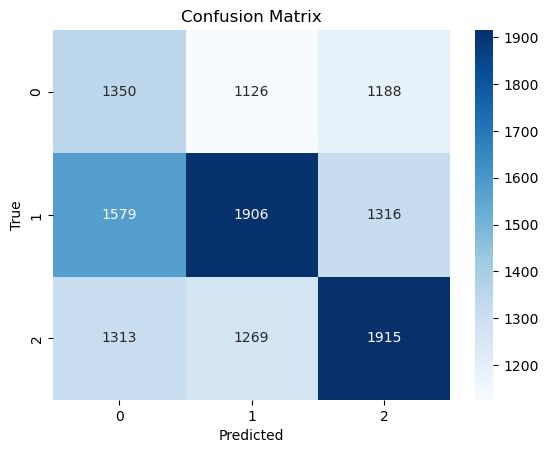

In [19]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb1000, y_pred_deb1000))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb1000, y_pred_deb1000)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [20]:
param_grid = [
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
        'l1_ratio': [0.3, 0.5, 0.7, 0.9],  # Slightly extended l1_ratio range
    },
    {
        'penalty': [None],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
]

grid_search_deb1000 = GridSearchCV(estimator=model_deb1000, param_grid = param_grid, scoring='accuracy', n_jobs=-1)
grid_result_deb1000 = grid_search_deb1000.fit(X_val_deb1000, y_val_deb1000)
# summarize results
print("Best: %f using %s" % (grid_result_deb1000.best_score_, grid_result_deb1000.best_params_))
means = grid_result_deb1000.cv_results_['mean_test_score']
stds = grid_result_deb1000.cv_results_['std_test_score']
params = grid_result_deb1000.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.634833 using {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.603129 (0.018759) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.604708 (0.016534) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.589056 (0.014365) with: {'C': 100, 'penalty': 'l2', 'solver': 'sag'}
0.614442 (0.016598) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.613390 (0.017112) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.613128 (0.017819) with: {'C': 10, 'penalty': 'l2', 'solver': 'sag'}
0.634833 (0.014873) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.634439 (0.014365) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.634439 (0.014278) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'sag'}
0.610496 (0.007835) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.609839 (0.007706) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.610233 (0.007825) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'sag'}
0.431464 (0.007745) with: {'C': 0.01, 'penalty': 'l

Accuracy: 0.3989
Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.37      0.34      3664
           1       0.44      0.40      0.42      4801
           2       0.43      0.43      0.43      4497

    accuracy                           0.40     12962
   macro avg       0.40      0.40      0.40     12962
weighted avg       0.40      0.40      0.40     12962

Confusion Matrix:
[[1350 1126 1188]
 [1579 1906 1316]
 [1313 1269 1915]]


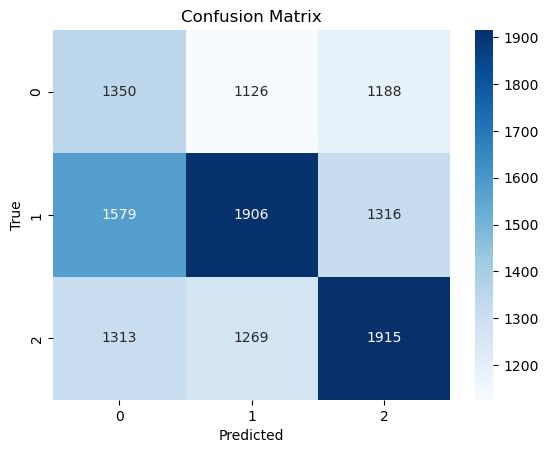

In [21]:
# Extract the best parameters
best_params_deb1000 = grid_result_deb1000.best_params_

# Update the model with the best parameters
best_model_deb1000 = LogisticRegression(**best_params_deb1000)
best_model_deb1000.fit(X_train_deb1000, y_train_deb1000) 

# Make predictions on the test set
y_pred_deb1000 = best_model_deb1000.predict(X_test_deb1000)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb1000, y_pred_deb1000)
print(f"Accuracy: {accuracy:.4f}")

# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb1000, y_pred_deb1000))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb1000, y_pred_deb1000)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

db500

In [23]:
# Step 4: Train the model
model_deb500 = LogisticRegression()
model_deb500.fit(X_train_deb500, y_train_deb500)

# Step 5: Evaluate the model
accuracy = model_deb500.score(X_test_deb500, y_test_deb500)
print(f"Accuracy: {accuracy}")

# Make predictions on the test set
y_pred_deb500 = model_deb500.predict(X_test_deb500)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb500, y_pred_deb500)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.38443141490510724
Accuracy: 0.3844


Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.35      0.33      3664
           1       0.43      0.39      0.41      4801
           2       0.42      0.41      0.41      4497

    accuracy                           0.38     12962
   macro avg       0.38      0.38      0.38     12962
weighted avg       0.39      0.38      0.39     12962

Confusion Matrix:
[[1296 1151 1217]
 [1596 1851 1354]
 [1394 1267 1836]]


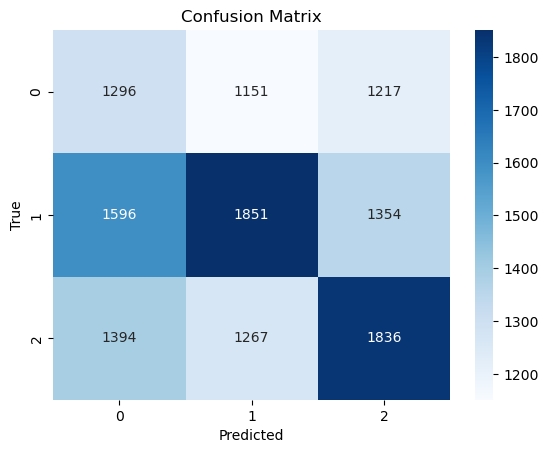

In [24]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb500, y_pred_deb500))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb500, y_pred_deb500)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [25]:
param_grid = [
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
        'l1_ratio': [0.3, 0.5, 0.7, 0.9],  # Slightly extended l1_ratio range
    },
    {
        'penalty': [None],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
]

grid_search_deb500 = GridSearchCV(estimator=model_deb500, param_grid = param_grid, scoring='accuracy', n_jobs=-1)
grid_result_deb500 = grid_search_deb500.fit(X_val_deb500, y_val_deb500)
# summarize results
print("Best: %f using %s" % (grid_result_deb500.best_score_, grid_result_deb500.best_params_))
means = grid_result_deb500.cv_results_['mean_test_score']
stds = grid_result_deb500.cv_results_['std_test_score']
params = grid_result_deb500.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.634966 using {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.596291 (0.016453) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.596027 (0.017219) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.578925 (0.012372) with: {'C': 100, 'penalty': 'l2', 'solver': 'sag'}
0.613523 (0.015143) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.611549 (0.015535) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.603922 (0.016524) with: {'C': 10, 'penalty': 'l2', 'solver': 'sag'}
0.634834 (0.014994) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.634966 (0.014003) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.634966 (0.014254) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'sag'}
0.606682 (0.009858) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.606682 (0.009916) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.606682 (0.009482) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'sag'}
0.433306 (0.006740) with: {'C': 0.01, 'penalty'

Accuracy: 0.3852
Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.35      0.33      3664
           1       0.43      0.39      0.41      4801
           2       0.42      0.41      0.41      4497

    accuracy                           0.39     12962
   macro avg       0.38      0.38      0.38     12962
weighted avg       0.39      0.39      0.39     12962

Confusion Matrix:
[[1294 1157 1213]
 [1598 1862 1341]
 [1393 1267 1837]]


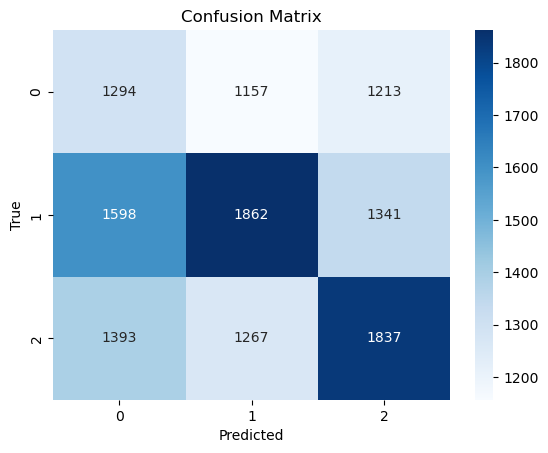

In [26]:
# Extract the best parameters
best_params_deb500 = grid_result_deb500.best_params_

# Update the model with the best parameters
best_model_deb500 = LogisticRegression(**best_params_deb500)
best_model_deb500.fit(X_train_deb500, y_train_deb500) 

# Make predictions on the test set
y_pred_deb500 = best_model_deb500.predict(X_test_deb500)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb500, y_pred_deb500)
print(f"Accuracy: {accuracy:.4f}")

# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb500, y_pred_deb500))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb500, y_pred_deb500)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

db100

In [28]:
# Step 4: Train the model
model_deb100 = LogisticRegression()
model_deb100.fit(X_train_deb100, y_train_deb100)

# Step 5: Evaluate the model
accuracy = model_deb100.score(X_test_deb100, y_test_deb100)
print(f"Accuracy: {accuracy}")

# Make predictions on the test set
y_pred_deb100 = model_deb100.predict(X_test_deb100)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb100, y_pred_deb100)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.38620583243326645
Accuracy: 0.3862


Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.34      0.33      3664
           1       0.43      0.41      0.42      4801
           2       0.41      0.40      0.40      4497

    accuracy                           0.39     12962
   macro avg       0.38      0.38      0.38     12962
weighted avg       0.39      0.39      0.39     12962

Confusion Matrix:
[[1261 1233 1170]
 [1471 1966 1364]
 [1358 1360 1779]]


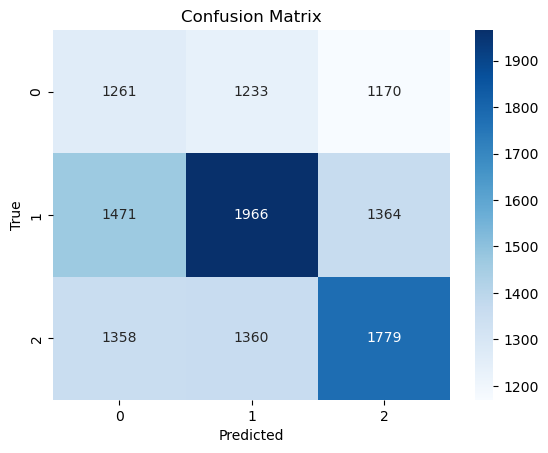

In [29]:
# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb100, y_pred_deb100))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb100, y_pred_deb100)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [30]:
param_grid = [
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
        'l1_ratio': [0.3, 0.5, 0.7, 0.9],  # Slightly extended l1_ratio range
    },
    {
        'penalty': [None],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
        'C': [100, 10, 1.0, 0.1, 0.01],
    },
]

grid_search_deb100 = GridSearchCV(estimator=model_deb100, param_grid = param_grid, scoring='accuracy', n_jobs=-1)
grid_result_deb100 = grid_search_deb100.fit(X_val_deb100, y_val_deb100)
# summarize results
print("Best: %f using %s" % (grid_result_deb100.best_score_, grid_result_deb100.best_params_))
means = grid_result_deb100.cv_results_['mean_test_score']
stds = grid_result_deb100.cv_results_['std_test_score']
params = grid_result_deb100.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.611290 using {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.577877 (0.017890) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.576693 (0.018273) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.569983 (0.013080) with: {'C': 100, 'penalty': 'l2', 'solver': 'sag'}
0.591032 (0.014434) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.591163 (0.014932) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.586822 (0.013928) with: {'C': 10, 'penalty': 'l2', 'solver': 'sag'}
0.611290 (0.015143) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.611158 (0.015651) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.611158 (0.015651) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'sag'}
0.598134 (0.015949) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.598133 (0.016356) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.597739 (0.016288) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'sag'}
0.413575 (0.009405) with: {'C': 0.01, 'penalty': 'l

Accuracy: 0.3862
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.34      0.33      3664
           1       0.43      0.41      0.42      4801
           2       0.41      0.40      0.40      4497

    accuracy                           0.39     12962
   macro avg       0.38      0.38      0.38     12962
weighted avg       0.39      0.39      0.39     12962

Confusion Matrix:
[[1261 1233 1170]
 [1471 1966 1364]
 [1358 1360 1779]]


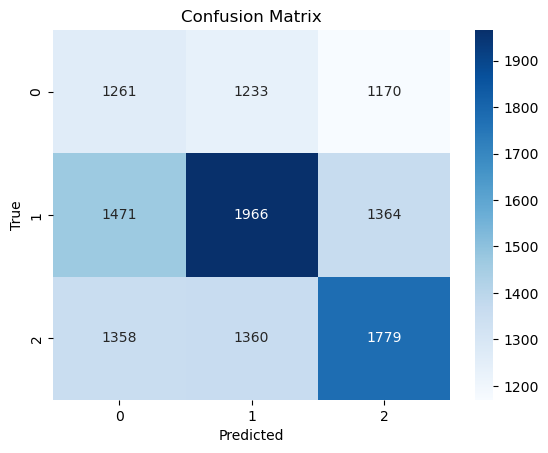

In [31]:
# Extract the best parameters
best_params_deb100 = grid_result_deb100.best_params_

# Update the model with the best parameters
best_model_deb100 = LogisticRegression(**best_params_deb100)
best_model_deb100.fit(X_train_deb100, y_train_deb100) 

# Make predictions on the test set
y_pred_deb100 = best_model_deb100.predict(X_test_deb100)

# Calculate Accuracy
accuracy = accuracy_score(y_test_deb100, y_pred_deb100)
print(f"Accuracy: {accuracy:.4f}")

# Generate Classification Report
print("Classification Report:")
print(classification_report(y_test_deb100, y_pred_deb100))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_deb100, y_pred_deb100)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()